# Dolomite surface titration in NaCl — speciation, calculated pH, surface charge

After **Pokrovsky et al. (1999)**. No surface complexation model is fitted or assumed. The workflow is:

* the carbonate system is treated as an **open system** with a **fixed pCO₂**, so CO₂(aq), HCO₃⁻ and CO₃²⁻ follow from pCO₂ and pH,
* the free ion concentrations (H⁺, Ca²⁺, Mg²⁺, Na⁺, Cl⁻) are the unknowns of the **mass balances** for Ca, Mg, Na and Cl,
* the **pH of every solution is calculated**, not taken from the electrode, from the reactive-ion charge balance,
* the **surface charge is the proton mass balance** between the conservative A+B mixture and the reacted suspension C — i.e. the net protons the dolomite surface took up or released.

Everything below is derived from the measured cation concentrations and the aqueous speciation only.

## 1. Molar masses and unit conversion

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import brentq, fsolve

# molar masses (g/mol)
mmNa, mmCl, mmCa, mmMg = 22.990, 35.453, 40.078, 24.305

def ppm_to_M(ppm, mm):
    """mg/L divided by g/mol -> mol/L"""
    return ppm / 1000.0 / mm

## 2. Equilibrium constants at 25 °C (log₁₀ K)

Reactions are written as dissociations (complex on the left, basis species on the right);
the number is the log K of that dissociation.

In [2]:
# carbonate system -- open system, pCO2 fixed
logKH = -1.468     # CO2(g)  = CO2(aq)      : [CO2aq] = 10**logKH * pCO2
logK1 = -6.345     # CO2(aq) + H2O = H+ + HCO3-
logK2 = -10.329    # HCO3-         = H+ + CO3^2-
logKw = -13.995    # H2O           = H+ + OH-

# metal-ligand complexes  (log K of the dissociation as written)
logK = {
    'CaCl':   0.696,   # CaCl+     = Ca2+ + Cl-
    'CaCO3':  7.002,   # CaCO3(aq) = Ca2+ + HCO3- - H+
    'CaHCO3':-1.047,   # CaHCO3+   = Ca2+ + HCO3-
    'CaOH':  12.850,   # CaOH+     = Ca2+ + H2O - H+
    'MgCl':   0.135,   # MgCl+     = Mg2+ + Cl-
    'MgCO3':  7.350,   # MgCO3(aq) = Mg2+ + HCO3- - H+
    'MgHCO3':-1.036,   # MgHCO3+   = Mg2+ + HCO3-
    'MgOH':  11.785,   # MgOH+     = Mg2+ + H2O - H+
    'NaCO3':  9.815,   # NaCO3-    = Na+ + HCO3- - H+
    'NaHCO3':-0.154,   # NaHCO3(aq)= Na+ + HCO3-
    'NaCl':   0.777,   # NaCl(aq)  = Na+ + Cl-
    'NaOH':  14.180,   # NaOH(aq)  = Na+ + H2O - H+
}

## 3. Law of mass action for every species

Given the free-ion concentrations `h=[H⁺], cCa=[Ca²⁺], cMg=[Mg²⁺], cNa=[Na⁺], cCl=[Cl⁻]`
and a fixed `pCO2`, every other species follows from a single mass-action law.

**Carbonate system (open, pCO₂ fixed):**

| reaction | resulting concentration |
|----------|-------------------------|
| CO₂(g) = CO₂(aq) | `[CO₂] = 10^logKH · pCO₂` |
| CO₂(aq) + H₂O = H⁺ + HCO₃⁻ | `[HCO₃⁻] = 10^logK1 · [CO₂] / [H⁺]` |
| HCO₃⁻ = H⁺ + CO₃²⁻ | `[CO₃²⁻] = 10^logK2 · [HCO₃⁻] / [H⁺]` |
| H₂O = H⁺ + OH⁻ | `[OH⁻] = 10^logKw / [H⁺]` |

**Complexes.** Each is written as a dissociation (complex on the left), so
`Kdiss = {basis species}/{complex}` and therefore `[complex] = {basis species} / Kdiss`,
with `Kdiss = 10^logK[name]`:

| reaction | resulting concentration |
|----------|-------------------------|
| CaCl⁺ = Ca²⁺ + Cl⁻ | `[Ca²⁺][Cl⁻] / 10^logK[CaCl]` |
| CaCO₃(aq) + H⁺ = Ca²⁺ + HCO₃⁻ | `[Ca²⁺][HCO₃⁻] / ([H⁺]·10^logK[CaCO3])` |
| CaHCO₃⁺ = Ca²⁺ + HCO₃⁻ | `[Ca²⁺][HCO₃⁻] / 10^logK[CaHCO3]` |
| CaOH⁺ + H⁺ = Ca²⁺ + H₂O | `[Ca²⁺] / ([H⁺]·10^logK[CaOH])` |

Magnesium and sodium follow the same pattern. Water activity is taken as 1
(concentration basis; see the closing note).

In [3]:
def all_species(h, cCa, cMg, cNa, cCl, pCO2):
    """Law of mass action for every aqueous species (mol/L)."""

    # ---- carbonate system + water (open system: CO2 set by pCO2) ----
    co2  = 10**logKH * pCO2            # CO2(g)        = CO2(aq)
    hco3 = 10**logK1 * co2  / h        # CO2(aq) + H2O = H+ + HCO3-
    co3  = 10**logK2 * hco3 / h        # HCO3-         = H+ + CO3^2-
    oh   = 10**logKw / h              # H2O           = H+ + OH-

    # ---- calcium complexes ----
    caCl   = cCa * cCl  / 10**logK['CaCl']          # CaCl+        = Ca2+ + Cl-
    caCO3  = cCa * hco3 / (h * 10**logK['CaCO3'])   # CaCO3(aq) + H+ = Ca2+ + HCO3-
    caHCO3 = cCa * hco3 / 10**logK['CaHCO3']        # CaHCO3+      = Ca2+ + HCO3-
    caOH   = cCa        / (h * 10**logK['CaOH'])     # CaOH+ + H+   = Ca2+ + H2O

    # ---- magnesium complexes ----
    mgCl   = cMg * cCl  / 10**logK['MgCl']          # MgCl+        = Mg2+ + Cl-
    mgCO3  = cMg * hco3 / (h * 10**logK['MgCO3'])   # MgCO3(aq) + H+ = Mg2+ + HCO3-
    mgHCO3 = cMg * hco3 / 10**logK['MgHCO3']        # MgHCO3+      = Mg2+ + HCO3-
    mgOH   = cMg        / (h * 10**logK['MgOH'])     # MgOH+ + H+   = Mg2+ + H2O

    # ---- sodium complexes ----
    naCO3  = cNa * hco3 / (h * 10**logK['NaCO3'])   # NaCO3- + H+  = Na+ + HCO3-
    naHCO3 = cNa * hco3 / 10**logK['NaHCO3']        # NaHCO3(aq)   = Na+ + HCO3-
    naCl   = cNa * cCl  / 10**logK['NaCl']          # NaCl(aq)     = Na+ + Cl-
    naOH   = cNa        / (h * 10**logK['NaOH'])     # NaOH(aq) + H+ = Na+ + H2O

    return {
        'H':   h,    'OH':   oh,    'CO2': co2, 'HCO3': hco3, 'CO3': co3,
        'Ca':  cCa,  'CaCl': caCl,  'CaCO3': caCO3, 'CaHCO3': caHCO3, 'CaOH': caOH,
        'Mg':  cMg,  'MgCl': mgCl,  'MgCO3': mgCO3, 'MgHCO3': mgHCO3, 'MgOH': mgOH,
        'Na':  cNa,  'NaCO3': naCO3, 'NaHCO3': naHCO3, 'NaCl': naCl, 'NaOH': naOH,
        'Cl':  cCl,
    }

## 4. Speciation solver — the mass balances

At a fixed pH and pCO₂ the four unknown free ions (Ca²⁺, Mg²⁺, Na⁺, Cl⁻) are found by
closing one **mass balance** per element: the measured total equals the free ion plus
everything it is bound into. There are no surface terms — no surface complexation model
is used.

```
Ca_total = [Ca²⁺] + [CaCl⁺] + [CaCO₃] + [CaHCO₃⁺] + [CaOH⁺]
Mg_total = [Mg²⁺] + [MgCl⁺] + [MgCO₃] + [MgHCO₃⁺] + [MgOH⁺]
Na_total = [Na⁺]  + [NaCO₃⁻] + [NaHCO₃] + [NaCl] + [NaOH]
Cl_total = [Cl⁻]  + [CaCl⁺] + [MgCl⁺] + [NaCl]
```

The totals come from the dissociation of the salts and titrant added
(NaCl = Na⁺ + Cl⁻, CaCl₂ = Ca²⁺ + 2Cl⁻, MgCl₂ = Mg²⁺ + 2Cl⁻, HCl = H⁺ + Cl⁻,
NaOH = Na⁺ + OH⁻); here they are taken straight from the measured ppm.

In [4]:
def solve_speciation(caT, mgT, naT, clT, pH, pCO2):
    """Solve the four element mass balances for the free ions at fixed pH and pCO2."""
    h = 10.0**(-pH)

    def residuals(x):
        cCa, cMg, cNa, cCl = [max(v, 1e-30) for v in x]
        s = all_species(h, cCa, cMg, cNa, cCl, pCO2)

        # each residual = (sum of species holding the element) - measured total
        ca_balance = (s['Ca'] + s['CaCl'] + s['CaCO3'] + s['CaHCO3'] + s['CaOH']) - caT
        mg_balance = (s['Mg'] + s['MgCl'] + s['MgCO3'] + s['MgHCO3'] + s['MgOH']) - mgT
        na_balance = (s['Na'] + s['NaCO3'] + s['NaHCO3'] + s['NaCl'] + s['NaOH']) - naT
        cl_balance = (s['Cl'] + s['CaCl'] + s['MgCl'] + s['NaCl'])              - clT
        return [ca_balance, mg_balance, na_balance, cl_balance]

    x0 = [max(caT, 1e-9), max(mgT, 1e-9), max(naT, 1e-9), max(clT, 1e-9)]
    x  = fsolve(residuals, x0, full_output=False)
    return all_species(h, *[max(v, 1e-30) for v in x], pCO2)

## 5. Charge balance → calculated pH

The pH of each solution is **calculated**, not read from the electrode. It is the pH at which the
reactive-ion charge balance equals the strong titrant added. The balance is written by group so each
role is explicit — protons, the DIC (carbonate) charge, the free divalent metals, and the chloride:

```
q_H   = +[H⁺]  − [OH⁻]                                   protons / hydroxide
q_DIC = −[HCO₃⁻] − 2[CO₃²⁻] − [NaCO₃⁻]                    charged carbonate  (CO₂, CaCO₃, MgCO₃, NaHCO₃ are neutral)
q_Ca  = +2[Ca²⁺] + [CaHCO₃⁺] + [CaOH⁺]                    free Ca²⁺ and its charged complexes
q_Mg  = +2[Mg²⁺] + [MgHCO₃⁺] + [MgOH⁺]                    free Mg²⁺ and its charged complexes
q_Na  = +[Na⁺]                                            free Na⁺   (background)
q_Cl  = −[Cl⁻]                                            free Cl⁻   (background)

sigma (reactive) = q_H + q_DIC + q_Ca + q_Mg   = net_acid   (net_acid = C_HCl − C_NaOH)
full electroneutrality = sigma + q_Na + q_Cl   = 0
```

`sigma` leaves out the indifferent background (free Na⁺ and Cl⁻) on purpose; the imbalance that
remains is what the mineral surface carries. The **full** balance keeps Na⁺ and Cl⁻ — for a perfectly
analysed solution it would be zero, but here the measured Na and Cl do not balance (off by up to
~1 mol/L), which is exactly why the pH is solved from `sigma` and not from the full balance.

**Carrying the titrant.** Vessel B is a bare NaCl blank whose pH is set entirely by the acid or base
used to preset it. Its tiny HCl/NaOH dose is buried in the analytical Na/Cl, so it enters the balance
explicitly as `net_acid`; without it every B run collapses to the same neutral pH. For untitrated
vessels `net_acid = 0`. (Charge coefficients corrected from earlier drafts: **NaCO₃⁻ is −1**, and
**NaHCO₃(aq) is neutral**.)

In [5]:
def total_DIC(s):
    """Total dissolved inorganic carbon (mol/L) = every carbon-bearing species."""
    return (s['CO2'] + s['HCO3'] + s['CO3']
            + s['CaCO3'] + s['CaHCO3'] + s['MgCO3'] + s['MgHCO3']
            + s['NaCO3'] + s['NaHCO3'])

def sigma(s):
    """
    Reactive-ion charge balance,  sum(z_i * c_i)  in equivalents/L, written by group.
    The indifferent background (free Na+ and free Cl-) is excluded; the imbalance that
    remains is what the mineral surface carries. Each term is (charge z) * (concentration).
    """
    q_H   = +1*s['H']   - 1*s['OH']                          # protons / hydroxide
    q_DIC = -1*s['HCO3'] - 2*s['CO3'] - 1*s['NaCO3']         # charged carbonate (DIC) species
    q_Ca  = +2*s['Ca']  + 1*s['CaHCO3'] + 1*s['CaOH']       # free Ca2+ and its charged complexes
    q_Mg  = +2*s['Mg']  + 1*s['MgHCO3'] + 1*s['MgOH']       # free Mg2+ and its charged complexes
    return q_H + q_DIC + q_Ca + q_Mg                         # Na+, Cl- excluded (background)

def charge_balance_full(s):
    """
    Full electroneutrality including the background electrolyte (eq/L):
        sigma(s) + [Na+] - [Cl-].
    Would be ~0 for a perfectly charge-balanced analysis; here the measured Na and Cl
    do not balance, so this is used only as a diagnostic, not to solve the pH.
    """
    return sigma(s) + 1*s['Na'] - 1*s['Cl']

def pH_from_charge(caT, mgT, naT, clT, pCO2, net_acid=0.0):
    """Calculated pH. `net_acid` = C_HCl - C_NaOH (mol/L) is the strong titrant added
    to a solution; it enters the balance as an explicit proton source, so the pH is
    found where sigma(pH) = net_acid. For untitrated vessels net_acid = 0."""
    f = lambda p: sigma(solve_speciation(caT, mgT, naT, clT, p, pCO2)) - net_acid
    ps = np.arange(1.0, 13.01, 0.2)
    vals = np.array([f(p) for p in ps])
    idx = np.where(np.sign(vals[:-1]) != np.sign(vals[1:]))[0]
    if len(idx) == 0:
        return np.nan
    k = idx[0]
    return brentq(f, ps[k], ps[k+1])

## 6. Proton mass balance → surface charge

Because the calculated pH is fixed by the reactive charge balance, that same charge sum is pinned
(zero for the untitrated vessels, `net_acid` for B) and cannot itself be the surface charge. The
surface charge is instead the **net proton exchange** between the conservative A+B mixture and the
reacted suspension C.

`TOTH` is the total proton excess of a solution relative to the reference components
(H₂O, CO₃²⁻, Ca²⁺, Mg²⁺, Na⁺, Cl⁻). The fixed-pCO₂ term (2·CO₂) is identical in every solution and
cancels in the mixture minus C difference, so the open-system CO₂ reservoir contributes nothing to the
surface charge.

```
sigma_H = ( TOTH_mix - TOTH_C ) / St
TOTH_mix = ( TOTH_A + TOTH_B ) / 2      (equal-volume 1:1 conservative mix)
```
`St` is the surface area per litre of vessel C (specific area × solid loading).

In [6]:
def TOTH(s):
    """
    Total proton excess (mol/L), referenced to components H2O, CO3^2-, Ca2+, Mg2+, Na+, Cl-.
    Each term is (protons released when the species forms from those components) * concentration.
    """
    return ( +1 * s['H']       # H+                         : +1
             -1 * s['OH']      # OH-    = H2O - H+           : -1
             +1 * s['HCO3']    # HCO3-  = CO3 + H+           : +1
             +2 * s['CO2']     # CO2    = CO3 + 2H+ - H2O    : +2 (constant, cancels in the mix - C)
             +1 * s['CaHCO3']  # CaHCO3+ = Ca + CO3 + H+     : +1
             -1 * s['CaOH']    # CaOH+   = Ca + H2O - H+     : -1
             +1 * s['MgHCO3']  # MgHCO3+ = Mg + CO3 + H+     : +1
             -1 * s['MgOH']    # MgOH+   = Mg + H2O - H+     : -1
             +1 * s['NaHCO3']  # NaHCO3  = Na + CO3 + H+     : +1
             -1 * s['NaOH'] )  # NaOH    = Na + H2O - H+     : -1

## 7. Fixed conditions and measured data (run-aligned)

`pCO2` is the single knob (default atmospheric, 10⁻³·⁵ atm). The three vessels are aligned by run,
so row *i* of A and B are the pair that was mixed to give row *i* of C. The measured pH is kept only
for comparison; it is never used in the speciation.

The strong titrant added to each B run is listed explicitly: runs 1–4 are HCl and runs 6–9 are NaOH,
in cumulative 0.001 mol/L steps (run 5 is the untitrated blank).

In [7]:
pCO2 = 10**-3.5          # atmospheric CO2 partial pressure (atm); change freely

# solid / solution amounts for the surface-charge normalisation
mass_solid = 6.0        # g of dolomite (all of it ends up in vessel C)
vol_C      = 0.200      # L in vessel C (100 mL A + 100 mL B)
SSA        = 0.84       # specific surface area, m2/g
loading    = mass_solid / vol_C          # g/L in vessel C  (= 30 g/L)
St         = SSA * loading                # m2 per litre of vessel C  (= 25.2)

# columns:  measured pH, Cl (ppm), Na (ppm), Ca (ppm), Mg (ppm)
# Vessel A : dolomite + NaCl, equilibrated
dataA = [
    [8.9, 48942, 27749.8, 29.4, 43.3],
    [8.8, 39648, 23604.3, 30.7, 42.7],
    [8.9, 42883, 34199.3, 28.3, 41.2],
    [9.0, 38612, 29672.0, 28.2, 41.6],
    [9.0, 33835, 24947.5, 30.1, 43.8],
    [8.8, 36206, 26775.3, 35.0, 49.5],
    [8.8, 32751, 24657.7, 31.0, 46.6],
    [9.0, 30515, 21705.0, 30.6, 45.1],
    [8.9, 32807, 23506.8, 35.7, 45.0],
]
# Vessel B : NaCl blank, pH pre-adjusted (Ca = Mg = 0). columns: pH, Cl, Na
dataB = [
    [2.4,  16937, 53900],
    [2.1,  17017, 32927],
    [2.1,  16827, 23180],
    [1.8,  16777, 24113],
    [5.5,  16838, 23718],
    [10.5, 16879, 21836],
    [10.6, 16854, 21302],
    [10.6, 16829, 21073],
    [10.8, 17022, 23484],
]
# strong titrant added to each B run (mol/L). runs 1-4 HCl, run 5 none, runs 6-9 NaOH,
# in cumulative 0.001 mol/L steps.
HCl_B  = [0.001, 0.002, 0.003, 0.004, 0.000, 0.000, 0.000, 0.000, 0.000]
NaOH_B = [0.000, 0.000, 0.000, 0.000, 0.000, 0.001, 0.002, 0.003, 0.004]
net_acid_B = [a - b for a, b in zip(HCl_B, NaOH_B)]    # C_HCl - C_NaOH
# Vessel C : mixture A + B after re-equilibration
dataC = [
    [7.5,  24901, 19593.1,  398.9, 114.2],
    [7.5,  32258, 23296.4,  560.6, 145.9],
    [7.2,  36300, 25729.3,  755.1, 180.4],
    [7.0,  26800, 16953.4, 1325.3, 233.9],
    [8.8,  24244, 16466.5,   37.2,  24.4],
    [9.8,  23699, 16183.2,   15.6,  13.6],
    [10.2, 21815, 14759.0,   16.3,   4.4],
    [10.2, 24118, 16450.8,   17.0,   3.6],
    [10.6, 22678, 15393.8,    9.8,   1.0],
]

## 8. Solve every sample at its calculated pH

For each vessel and run: convert ppm to mol/L, find the calculated pH from the charge balance,
build the full speciation at that pH, and record TOTH.

In [8]:
def totals(row):
    if len(row) == 3:                 # vessel B (no Ca, Mg)
        pHm, clp, nap = row; cap = mgp = 0.0
    else:
        pHm, clp, nap, cap, mgp = row
    return (ppm_to_M(cap, mmCa), ppm_to_M(mgp, mmMg),
            ppm_to_M(nap, mmNa), ppm_to_M(clp, mmCl), pHm)

def analyse(row, pCO2, net_acid=0.0):
    caT, mgT, naT, clT, pHm = totals(row)
    pHc = pH_from_charge(caT, mgT, naT, clT, pCO2, net_acid)
    s   = solve_speciation(caT, mgT, naT, clT, pHc, pCO2) if np.isfinite(pHc) else None
    return {'pHmeas': pHm, 'pHcalc': pHc, 'spec': s,
            'TOTH': (TOTH(s) if s is not None else np.nan)}

resA = [analyse(r, pCO2) for r in dataA]
resB = [analyse(r, pCO2, net_acid_B[i]) for i, r in enumerate(dataB)]   # carry the titrant
resC = [analyse(r, pCO2) for r in dataC]

## 9. Calculated pH (measured shown only for comparison)

**Read the calculated pH of vessel C as an internal reference, not a prediction of the electrode.**
It runs opposite to the measured pH on purpose-built grounds, and it is worth knowing why:

* Vessel C's pH is solved from the reactive charge balance, which leaves out free Na⁺ and Cl⁻.
* In the acid runs (1–4) a lot of dolomite dissolved, so C carries a high load of Ca²⁺ and Mg²⁺.
  Those cations are balanced in reality by the chloride from the HCl — but chloride is exactly what
  the reactive balance excludes, so the model has to balance them with carbonate instead, which at a
  fixed atmospheric pCO₂ forces the pH **up** (≈9.2–9.4).
* In the base runs (6–9) almost nothing dissolved, so there is little Ca²⁺/Mg²⁺ to balance and the
  calculated pH sits **lower** (≈8.0–8.4).

The result is a calculated C pH that tracks how much dolomite dissolved and is nearly anti-correlated
with the electrode reading. That is a known consequence of combining an open system, a calculated pH,
and a reactive balance that omits the background electrolyte; the electrode pH is the physical value
and is listed alongside for comparison. See note 3 for the options if a physical C pH is needed.

In [9]:
def pH_table(res, label):
    rows = {}
    for i, r in enumerate(res):
        s = r['spec']
        rows[f'run {i+1}'] = {
            'pH measured':   r['pHmeas'],
            'pH calculated': round(r['pHcalc'], 2) if np.isfinite(r['pHcalc']) else np.nan,
            'H+ (mol/L)':    (s['H']  if s else np.nan),
            'DIC (mol/L)':   (total_DIC(s) if s else np.nan),
            'free Ca2+':     (s['Ca'] if s else np.nan),
            'free Mg2+':     (s['Mg'] if s else np.nan),
            'free Cl- ':     (s['Cl'] if s else np.nan),
            'charge bal.':   (charge_balance_full(s) if s else np.nan),  # ~0 only if Na,Cl balanced
        }
    df = pd.DataFrame(rows).T
    df.index.name = f'Vessel {label}'
    return df

for lab, res in [('A', resA), ('B', resB), ('C', resC)]:
    print(f'--- Vessel {lab}: pH, DIC, free ions and the full charge balance ---')
    print(pH_table(res, lab).to_string(float_format=lambda x: f'{x:.3g}'))
    print()

--- Vessel A: pH, DIC, free ions and the full charge balance ---
          pH measured  pH calculated  H+ (mol/L)  DIC (mol/L)  free Ca2+  free Mg2+  free Cl-   charge bal.
Vessel A                                                                                                   
run 1             8.9           8.72    1.89e-09       0.0067   0.000523   0.000911       1.18       -0.176
run 2             8.8           8.75    1.78e-09      0.00666   0.000555   0.000969      0.974      -0.0944
run 3             8.9           8.72    1.91e-09      0.00767   0.000518   0.000932      0.997        0.274
run 4               9           8.73    1.84e-09      0.00733   0.000519   0.000969      0.917        0.198
run 5               9           8.77     1.7e-09      0.00727   0.000551    0.00105      0.823        0.127
run 6             8.8           8.81    1.56e-09       0.0083    0.00062    0.00116      0.873        0.139
run 7             8.8           8.79    1.63e-09      0.00762   0.00056

## 10. Speciation at the calculated pH  (species in rows, runs in columns, mol/L)

In [10]:
species_order = ['H','OH','CO2','HCO3','CO3',
                 'Ca','CaCl','CaCO3','CaHCO3','CaOH',
                 'Mg','MgCl','MgCO3','MgHCO3','MgOH',
                 'Na','NaCO3','NaHCO3','NaCl','NaOH','Cl']

def speciation_table(res, label):
    cols = {}
    for i, r in enumerate(res):
        s = r['spec']
        cols[f'run {i+1}'] = [ (s[k] if s is not None else np.nan) for k in species_order ]
    df = pd.DataFrame(cols, index=species_order)
    df.index.name = f'Vessel {label} (mol/L)'
    return df

for lab, res in [('A', resA), ('B', resB), ('C', resC)]:
    print(f'--- Vessel {lab}: speciation at the calculated pH ---')
    print(speciation_table(res, lab).to_string(float_format=lambda x: f'{x:.3e}'))
    print()

--- Vessel A: speciation at the calculated pH ---
                     run 1     run 2     run 3     run 4     run 5     run 6     run 7     run 8     run 9
Vessel A (mol/L)                                                                                          
H                1.893e-09 1.777e-09 1.907e-09 1.845e-09 1.704e-09 1.564e-09 1.626e-09 1.630e-09 1.590e-09
OH               5.343e-06 5.692e-06 5.305e-06 5.483e-06 5.935e-06 6.469e-06 6.221e-06 6.207e-06 6.360e-06
CO2              1.076e-05 1.076e-05 1.076e-05 1.076e-05 1.076e-05 1.076e-05 1.076e-05 1.076e-05 1.076e-05
HCO3             2.569e-03 2.737e-03 2.551e-03 2.637e-03 2.854e-03 3.111e-03 2.991e-03 2.985e-03 3.058e-03
CO3              6.362e-05 7.219e-05 6.271e-05 6.700e-05 7.849e-05 9.326e-05 8.624e-05 8.587e-05 9.015e-05
Ca               5.234e-04 5.551e-04 5.183e-04 5.187e-04 5.505e-04 6.200e-04 5.617e-04 5.583e-04 6.420e-04
CaCl             1.245e-04 1.089e-04 1.041e-04 9.583e-05 9.123e-05 1.090e-04 9.019e-05 8.484e-

## 11. Surface charge from the proton mass balance

For each run the conservative reference is the 1:1 mix of A and B, `TOTH_mix = (TOTH_A + TOTH_B)/2`.
The surface charge is `sigma_H = (TOTH_mix - TOTH_C)/St`, reported per m² of dolomite. A positive value
means the surface released protons (net negative sites neutralised); a negative value means the surface
consumed protons. Runs 1–4 have strong incongruent dissolution (high dissolved Ca, Mg), so their values
are dominated by carbonate released into solution rather than by simple surface protonation.

In [11]:
rows = []
for i in range(9):
    tmix = 0.5 * (resA[i]['TOTH'] + resB[i]['TOTH'])
    tC   = resC[i]['TOTH']
    sigmaH = (tmix - tC) / St            # eq / m2
    rows.append({
        'run':            i + 1,
        'pH_calc (C)':    round(resC[i]['pHcalc'], 2),
        'pH_meas (C)':    resC[i]['pHmeas'],
        'TOTH_mix (mol/L)': tmix,
        'TOTH_C (mol/L)':   tC,
        'sigma_H (mmol/m2)': sigmaH * 1e3,
    })
surf = pd.DataFrame(rows).set_index('run')
print(surf.to_string(float_format=lambda x: f'{x:.4g}'))

     pH_calc (C)  pH_meas (C)  TOTH_mix (mol/L)  TOTH_C (mol/L)  sigma_H (mmol/m2)
run                                                                               
1           9.25          7.5          0.003662         0.01863             -0.594
2            9.3          7.5          0.004124         0.02263            -0.7343
3           9.34          7.2          0.005123         0.02635            -0.8422
4           9.44            7          0.005452         0.02719            -0.8624
5           8.72          8.8          0.003405        0.004917              -0.06
6           8.45          9.8          0.004925         0.00262            0.09147
7           8.28         10.2          0.005599        0.001742              0.153
8           8.27         10.2          0.006264        0.001773             0.1782
9              8         10.6           0.00755       0.0009239              0.263


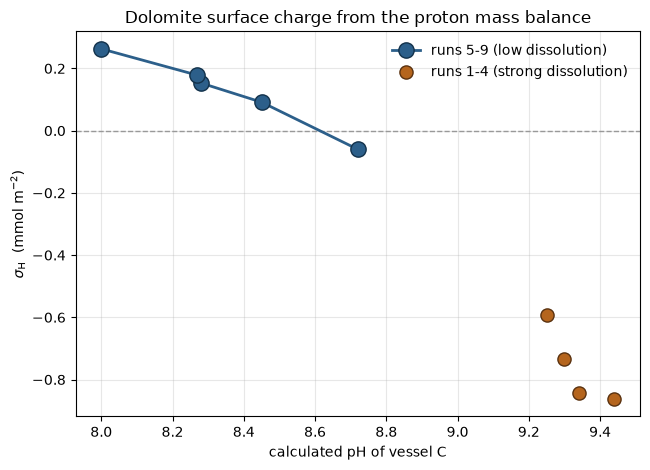

In [12]:
fig, ax = plt.subplots(figsize=(6.6, 4.8))
ax.axhline(0, color='0.6', lw=1.0, ls='--')

low  = surf[surf.index >= 5]     # little dissolution -> clean surface titration
high = surf[surf.index <= 4]     # strong dissolution

ax.plot(low['pH_calc (C)'], low['sigma_H (mmol/m2)'], '-o',
        color='#2c5f8a', mec='#12314a', ms=11, lw=2, label='runs 5-9 (low dissolution)')
ax.scatter(high['pH_calc (C)'], high['sigma_H (mmol/m2)'],
           color='#b5651d', ec='#5a3210', s=90, zorder=3, label='runs 1-4 (strong dissolution)')

ax.set_xlabel('calculated pH of vessel C')
ax.set_ylabel(r'$\sigma_\mathrm{H}$  (mmol m$^{-2}$)')
ax.set_title('Dolomite surface charge from the proton mass balance')
ax.legend(frameon=False)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('surface_charge_vs_pH.png', dpi=150)
plt.show()

## Notes

1. **No surface complexation model.** The surface charge is a proton mass balance between the
   conservative A+B mixture and the reacted suspension C — no site densities and no surface
   equilibrium constants are used.
2. **Open system.** CO₂(aq) is fixed by pCO₂, so the carbonate speciation follows from pCO₂ and pH.
   The fixed-CO₂ term cancels in the surface-charge difference.
3. **Calculated pH, and the backwards vessel C.** Every pH is obtained from the reactive-ion charge
   balance; the electrode reading is shown only for comparison. Forcing an open system *and* a
   calculated pH detaches the model pH from the experiment. It shows up most clearly in vessel C
   (section 9): the calculated C pH is driven by how much dolomite dissolved and runs nearly opposite
   to the electrode, because the dissolved Ca²⁺/Mg²⁺ are balanced in reality by chloride, which the
   reactive balance omits. This is kept on purpose here — the calculated C pH is an internal
   reference only. If a physical C pH is wanted, the fixes are to use the measured pH for the final
   speciation, to use the measured carbonate (closed system) instead of atmospheric pCO₂, or to fit
   pCO₂ per run to the measured DIC; any of these bounds the high-pH carbonate and restores the
   expected acid-low / base-high order.
4. **Titrant carried explicitly.** The HCl / NaOH used to preset each B run enters the balance as a
   proton source (`net_acid_B`). This restores a distinct pH for every B run instead of a single
   neutral value, and it feeds the mixture reference `TOTH_mix` that sets the surface charge. On the
   base side the calculated pH (≈8.3–8.9) is lower than the measured 10.5–10.8, because at fixed
   atmospheric pCO₂ the added base is partly spent drawing CO₂ into bicarbonate — an open-system
   consequence, not an error in carrying the titrant. Lower `pCO2` to loosen that buffering.
5. **Activity coefficients = 1.** At the high ionic strength of these NaCl solutions a Davies / SIT /
   Pitzer correction would shift the numbers; add gamma factors inside `all_species` if needed.
6. **Charge coefficients.** NaCO₃⁻ carries −1 (not −2) and NaHCO₃(aq) is neutral; both were corrected
   in `sigma`.